In [ ]:
import pandas as pd

df = pd.read_excel("Whatisloneliness060321.xlsx")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.9 MB/s eta 0:00:00


Inspecting the data

In [ ]:
df.head()
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55203 entries, 0 to 55202
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Idme                        55203 non-null  int64  
 1   gender                      49019 non-null  float64
 2   groupedage                  54974 non-null  float64
 3   age                         47381 non-null  float64
 4   UCLA3itemscale              46858 non-null  float64
 5   Q9_Loneliness_Meaning_Qual  55202 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 2.5+ MB


Index(['Idme', 'gender', 'groupedage', 'age', 'UCLA3itemscale',
       'Q9_Loneliness_Meaning_Qual'],
      dtype='object')

get the text colmn

In [ ]:
df["Q9_Loneliness_Meaning_Qual"].head(10)


,Q9_Loneliness_Meaning_Qual
0,-99
1,Makes me feel empty
2,Not speaking to anyone for days. Being out wit...
3,I am a very loving generous person but due to ...
4,Unlikeable
5,Feeling like you aren't connected to the world...
6,being alone when you dont want to be. a feelin...
7,Being lonely is not the same as being alone. ...
8,Loneliness is inability to share with others.
9,Feeling apart and disconnected from other peop...


legitmacy checks

In [ ]:
len(df)


55203

Missing text values

In [ ]:
df["Q9_Loneliness_Meaning_Qual"].isna().sum()


np.int64(1)

Extract and clean the text column

In [ ]:
# Keep only the text column
texts = df["Q9_Loneliness_Meaning_Qual"].dropna().astype(str)

# Convert to list (needed later)
documents = texts.tolist()

len(documents)


55202

the raw text (legit check)

In [ ]:
documents[:10]


['-99',
 'Makes me feel empty',
 "Not speaking to anyone for days. Being out with someone and they just sit in there phone. Feeling like I'm unwanted. Feeling like no one cares for you. You could be out with friends and family and feel physically sick cause you just don't feel like you're apart of the group. You message your partner and he doesn't ever reply. ",
 'I am a very loving generous person but due to an alcohol issue my wife had and her unfaithfulness my beautiful family have been severely damaged. The daughter that meant the world to me has not had contact for over 10 years. It destroyed me more than anything. I have missed out on two beautiful granddaughters ',
 'Unlikeable',
 "Feeling like you aren't connected to the world, FOMO, having too much time to think by yourself",
 'being alone when you dont want to be. a feeling you cant escape',
 "Being lonely is not the same as being alone.  I like to spend time alone but I don't like to be lonely. Loneliness means lack of conne

Basic text length analysis, just enough

In [ ]:
import numpy as np

lengths = [len(doc.split()) for doc in documents]

print("Average length:", np.mean(lengths))
print("Median length:", np.median(lengths))
print("Min length:", np.min(lengths))
print("Max length:", np.max(lengths))


Average length: 19.820749248215645
Median length: 11.0
Min length: 0
Max length: 3167


Set up NLP tools

In [ ]:
!pip install -q spacy nltk
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


mport libraries & setup

In [ ]:
import spacy
import nltk
from nltk.corpus import stopwords
import re


Download NLTK stopwords

In [ ]:
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Load spaCy model:

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])


Define stopwords

In [ ]:
stop_words = set(stopwords.words("english"))


adding domain-neutral fillers

In [ ]:
custom_stopwords = {"thing", "things", "something", "someone"}
stop_words = stop_words.union(custom_stopwords)


Building the preprocessing function

In [ ]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove non-letter characters
    text = re.sub(r"[^a-z\s]", "", text)

    # spaCy processing
    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if token.lemma_ not in stop_words
        and len(token.lemma_) > 2
    ]

    return " ".join(tokens)


Testing preprocessing



In [ ]:
sample_text = documents[0]
print("ORIGINAL:\n", sample_text)
print("\nPROCESSED:\n", preprocess_text(sample_text))


ORIGINAL:
 -99

PROCESSED:
 


Filter out invalid responses

In [ ]:
# removing known invalid placeholders
invalid_values = {"-99", "-99.0", "99", "n/a", "na", "none", ""}

clean_texts = [
    doc for doc in documents
    if doc.strip().lower() not in invalid_values
]

len(clean_texts)



39432

run preprocessing to dataset

In [ ]:
processed_documents = [preprocess_text(doc) for doc in clean_texts]


extra safety filter

In [ ]:
processed_documents = [
    doc for doc in processed_documents if len(doc.split()) > 2
]


retesting preprocessing

In [ ]:
sample_text = clean_texts[0]
print("ORIGINAL:\n", sample_text)
print("\nPROCESSED:\n", preprocess_text(sample_text))


ORIGINAL:
 Makes me feel empty

PROCESSED:
 make feel empty


Vectorizing the text

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_df=0.95,      # ignore very common words
    min_df=5,         # ignore very rare words
    stop_words="english"
)

dtm = vectorizer.fit_transform(processed_documents)

Check shape

In [ ]:
dtm.shape

(35717, 3446)

Training LDA model

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

num_topics = 5  # can be tune later

lda_model = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42
)

lda_model.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

Display topics

In [ ]:
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [words[i] for i in topic.argsort()[-10:]]
    print(f"\nTopic {topic_idx + 1}:")
    print(", ".join(top_words))


Topic 1:
mean, idea, loneliness, feeling, life, able, experience, talk, thought, share

Topic 2:
self, company, interaction, social, human, isolation, connection, day, contact, lack

Topic 3:
world, need, support, isolate, isolation, people, isolated, loneliness, feeling, feel

Topic 4:
understand, mean, want, talk, lonely, loneliness, time, like, people, feel

Topic 5:
make, work, time, people, life, live, family, lonely, loneliness, friend


installing Gensim (for coherence)

In [ ]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.0 MB/s eta 0:00:00


Prepare data for Gensim

In [ ]:
tokenized_docs = [doc.split() for doc in processed_documents]

Create dictionary and corpus

In [ ]:
from gensim.corpora import Dictionary

dictionary = Dictionary(tokenized_docs)

corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

Train Gensim LDA for evaluation only

In [ ]:
from gensim.models import LdaModel

gensim_lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,   # same as your sklearn model
    random_state=42,
    passes=10
)

Compute coherence score

In [ ]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=gensim_lda,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v"
)

coherence_score = coherence_model.get_coherence()

print("Coherence Score:", coherence_score)

Coherence Score: 0.6017405312131424


tuning number of topic

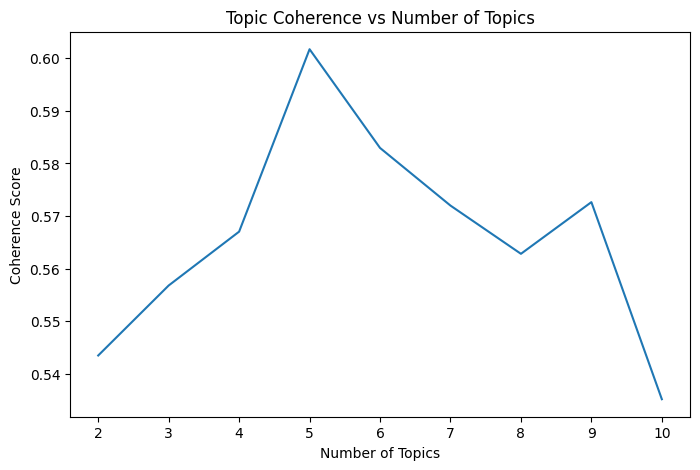

In [ ]:
import matplotlib.pyplot as plt

topic_range = range(2, 11)
scores = []

for k in topic_range:
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10
    )

    cm = CoherenceModel(
        model=lda,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )

    scores.append(cm.get_coherence())

# Plot
plt.figure(figsize=(8,5))
plt.plot(topic_range, scores)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Topic Coherence vs Number of Topics")
plt.show()

Install pyLDAvis

In [ ]:
!pip install -q pyldavis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.1 MB/s eta 0:00:00


Import librarie

In [ ]:
import pyLDAvis.gensim as gensimvis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Prepare the visualization

In [ ]:
vis = gensimvis.prepare(
    gensim_lda,   #  trained gensim LDA model
    corpus,
    dictionary
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Display the pyLDAvis Map

In [ ]:
# running this to see the interactive map
import pyLDAvis

# Enabling notebook mode to display the plot inline
pyLDAvis.enable_notebook()

# Displaying the visualization
pyLDAvis.display(vis)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Implement NMF

In [ ]:
# NMF Implementation (5 Topics)
from sklearn.decomposition import NMF

print("Training NMF Model with k=5...")

#  Initializing NMF with 5 components
nmf_model = NMF(
    n_components=5,
    random_state=42,
    init='nndsvd',
    max_iter=500
)

# Fitting the model
nmf_model.fit(dtm)

# Reusable function to display topics
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        # Find the indices of the words with the highest weights
        top_word_indices = topic.argsort()[:-no_top_words - 1:-1]
        # Join the words into a single string
        top_words = " ".join([feature_names[i] for i in top_word_indices])
        print(f"Topic {topic_idx}:")
        print(top_words, "\n")

# Executing the display
feature_names = vectorizer.get_feature_names_out()
display_topics(nmf_model, feature_names, 10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Training NMF Model with k=5...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Topic 0:
feel like lonely understand isolated make feeling talk care sad 

Topic 1:
friend time lonely life make family year work live think 

Topic 2:
loneliness mean life think experience person need want sense different 

Topic 3:
people know want lack like understand surround contact connection talk 

Topic 4:
share feeling talk thought experience life able lack time isolation 



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

BERTopic Implementation

In [ ]:
#BERTopic Implementation
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired

# defining the representation model (makes topics cleaner)
representation_model = KeyBERTInspired()

# Initialize BERTopic
# calculate_probabilities=True is what powers the bar chart
model = BERTopic(
    nr_topics=5,
    calculate_probabilities=True,
    representation_model=representation_model,
    verbose=False
)

print("Training BERTopic on loneliness narratives...")

# using clean_texts because it has original word order which helps BERT
topics, probs = model.fit_transform(clean_texts)
# Manual Topic Labeling
topic_labels = {
    0: "Emotional Distress",
    1: "Situational/Life Factors",
    2: "Conceptual/Existential Loneliness",
    3: "Lack of Social Connection",
    4: "Communication Barriers"
}
model.set_topic_labels(topic_labels)

# saving the trained model for app
model.save("loneliness_bertopic_model", serialization="safetensors", save_ctfidf=True)
print("Model saved! Please download the 'loneliness_bertopic_model' folder.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Training BERTopic on loneliness narratives...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Batches:   0%|          | 0/1233 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(d

Model saved! Please download the 'loneliness_bertopic_model' folder.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

NMF Model Aand Vectorizer and Bertopic Model downloading

In [ ]:
import joblib
import shutil
from google.colab import files

def save_and_download_models(nmf, vec, bert):
    print("Saving all models...")

    # Save NMF and Vectorizer
    joblib.dump(nmf, 'nmf_model.pkl')
    joblib.dump(vec, 'vectorizer.pkl')

    # BERTopic folder and zip it
    bert.save("loneliness_bertopic_model", serialization="safetensors", save_ctfidf=True)
    shutil.make_archive("loneliness_bertopic_model", 'zip', "loneliness_bertopic_model")

    # Download files
    files.download('nmf_model.pkl')
    files.download('vectorizer.pkl')
    files.download('loneliness_bertopic_model.zip')
    print("Download initiated!")

#calling the functions
save_and_download_models(nmf_model, vectorizer, model)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saving all models...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

Download initiated!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# function to display the top words for each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

# get the word names from vectorizer
tf_feature_names = vectorizer.get_feature_names_out()

#display the top 10 words for each  topics
display_topics(nmf_model, tf_feature_names, 10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Topic 0:
feel like lonely understand isolated make feeling talk care sad
Topic 1:
friend time lonely life make family year work live think
Topic 2:
loneliness mean life think experience person need want sense different
Topic 3:
people know want lack like understand surround contact connection talk
Topic 4:
share feeling talk thought experience life able lack time isolation


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
joblib.dump(lda_model, 'lda_model.pkl')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

['lda_model.pkl']

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
